In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# 强制只用CPU运行，避开GPU问题
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ====================== 1. 确认数据集路径 ======================
# Kaggle 挂载后的默认路径，直接用就行
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
print("数据集路径检查:")
print(os.listdir(base_path))

# 训练/测试/验证文件夹路径
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
val_dir = os.path.join(base_path, 'val')

print("\n训练集文件夹检查:")
print(os.listdir(train_dir))
print(f"正常胸片数量: {len(os.listdir(os.path.join(train_dir, 'NORMAL')))}")
print(f"肺炎胸片数量: {len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))}")

# ====================== 2. 数据加载（Kaggle最稳定方式） ======================
IMG_SIZE = (128, 128)  # 降低分辨率，CPU跑得更快
BATCH_SIZE = 32

# 训练集：带简单数据增强
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 直接在这里按8:2划分训练/验证集，避开你之前的错误
)

# 从train文件夹生成训练集（80%）
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    subset='training',
    seed=42
)

# 从train文件夹生成验证集（20%）
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    subset='validation',
    seed=42
)

# 测试集：只做归一化，不打乱
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

print(f"\n✅ 训练集样本数: {train_generator.samples}")
print(f"✅ 验证集样本数: {val_generator.samples}")
print(f"✅ 测试集样本数: {test_generator.samples}")

# ====================== 3. 搭建轻量CNN模型（CPU友好） ======================
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # 二分类输出
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n模型结构:")
model.summary()

# ====================== 4. 训练模型 ======================
print("\n🚀 开始训练（CPU约5-10分钟跑完）...")
history = model.fit(
    train_generator,
    epochs=8,  # 少跑几轮，节省时间
    validation_data=val_generator,
    verbose=1
)

# ====================== 5. 训练曲线可视化 ======================
plt.figure(figsize=(12, 4))

# 准确率曲线
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='训练准确率')
plt.plot(history.history['val_accuracy'], label='验证准确率')
plt.title('模型准确率变化')
plt.legend()

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('模型损失变化')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png')
plt.show()

# ====================== 6. 测试集评估（作业要求的全部指标） ======================
print("\n📊 测试集评估结果:")
test_loss, test_acc = model.evaluate(test_generator)
print(f"测试集准确率: {test_acc:.4f}")

# 获取预测结果
y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 打印完整分类报告（精确率、召回率、F1分数）
print("\n===== 分类报告 =====")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

数据集路径检查:


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/chest-xray-pneumonia/chest_xray'

In [4]:
# 强制只用CPU运行，避开GPU问题
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ====================== 1. 自动找对数据集路径 ======================
print("=== 正在自动查找数据集路径 ===")
input_dir = '/kaggle/input'
print("Input目录下的文件夹:", os.listdir(input_dir))

# 自动找到chest-xray-pneumonia的路径
dataset_name = 'chest-xray-pneumonia'
dataset_path = None
for folder in os.listdir(input_dir):
    if dataset_name in folder:
        dataset_path = os.path.join(input_dir, folder)
        break

if dataset_path is None:
    print("❌ 没找到数据集，请确认你已经挂载了 Chest X-Ray Images (Pneumonia)")
else:
    print(f"✅ 找到数据集路径: {dataset_path}")
    print("数据集里的内容:", os.listdir(dataset_path))

    # 再找chest_xray文件夹
    if 'chest_xray' in os.listdir(dataset_path):
        base_path = os.path.join(dataset_path, 'chest_xray')
    else:
        base_path = dataset_path

    print(f"✅ 最终数据路径: {base_path}")
    print("数据路径里的内容:", os.listdir(base_path))

    # 训练/测试/验证文件夹路径
    train_dir = os.path.join(base_path, 'train')
    test_dir = os.path.join(base_path, 'test')
    val_dir = os.path.join(base_path, 'val')

    print(f"\n训练集路径检查: {train_dir}")
    print("训练集里的文件夹:", os.listdir(train_dir))
    print(f"正常胸片数量: {len(os.listdir(os.path.join(train_dir, 'NORMAL')))}")
    print(f"肺炎胸片数量: {len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))}")

    # ====================== 2. 数据加载（Kaggle最稳定方式） ======================
    IMG_SIZE = (128, 128)  # 降低分辨率，CPU跑得更快
    BATCH_SIZE = 32

    # 训练集：带简单数据增强
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        validation_split=0.2  # 直接在这里按8:2划分训练/验证集
    )

    # 从train文件夹生成训练集（80%）
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        subset='training',
        seed=42
    )

    # 从train文件夹生成验证集（20%）
    val_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        subset='validation',
        seed=42
    )

    # 测试集：只做归一化，不打乱
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        shuffle=False
    )

    print(f"\n✅ 训练集样本数: {train_generator.samples}")
    print(f"✅ 验证集样本数: {val_generator.samples}")
    print(f"✅ 测试集样本数: {test_generator.samples}")

    # ====================== 3. 搭建轻量CNN模型（CPU友好） ======================
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # 二分类输出
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    print("\n模型结构:")
    model.summary()

    # ====================== 4. 训练模型 ======================
    print("\n🚀 开始训练（CPU约5-10分钟跑完）...")
    history = model.fit(
        train_generator,
        epochs=8,  # 少跑几轮，节省时间
        validation_data=val_generator,
        verbose=1
    )

    # ====================== 5. 训练曲线可视化 ======================
    plt.figure(figsize=(12, 4))

    # 准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='训练准确率')
    plt.plot(history.history['val_accuracy'], label='验证准确率')
    plt.title('模型准确率变化')
    plt.legend()

    # 损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.title('模型损失变化')
    plt.legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png')
    plt.show()

    # ====================== 6. 测试集评估（作业要求的全部指标） ======================
    print("\n📊 测试集评估结果:")
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"测试集准确率: {test_acc:.4f}")

    # 获取预测结果
    y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
    y_true = test_generator.classes

    # 打印完整分类报告（精确率、召回率、F1分数）
    print("\n===== 分类报告 =====")
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

    # 混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title('混淆矩阵')
    plt.savefig('/kaggle/working/confusion_matrix.png')
    plt.show()

=== 正在自动查找数据集路径 ===
Input目录下的文件夹: ['datasets']
❌ 没找到数据集，请确认你已经挂载了 Chest X-Ray Images (Pneumonia)


In [5]:
# 强制只用CPU运行，避开GPU问题
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ====================== 1. 自动识别数据集路径 ======================
print("=== 自动查找数据集路径 ===")
input_dir = '/kaggle/input'
dataset_path = os.path.join(input_dir, 'chest-xray-pneumonia')
if not os.path.exists(dataset_path):
    dataset_path = None
    for folder in os.listdir(input_dir):
        if 'chest-xray-pneumonia' in folder:
            dataset_path = os.path.join(input_dir, folder)
            break

if dataset_path is None:
    print("❌ 未找到数据集，请确认已挂载 Chest X-Ray Images (Pneumonia)")
else:
    base_path = os.path.join(dataset_path, 'chest_xray')
    print(f"✅ 数据集路径: {base_path}")

    # 定义路径
    train_dir = os.path.join(base_path, 'train')
    test_dir = os.path.join(base_path, 'test')

    # 统计数据分布（作业要求）
    print("\n=== 数据集统计 ===")
    train_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
    train_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
    test_normal = len(os.listdir(os.path.join(test_dir, 'NORMAL')))
    test_pneumonia = len(os.listdir(os.path.join(test_dir, 'PNEUMONIA')))

    print(f"训练集：NORMAL={train_normal}, PNEUMONIA={train_pneumonia}")
    print(f"测试集：NORMAL={test_normal}, PNEUMONIA={test_pneumonia}")

    # ====================== 2. 数据加载与预处理（按8:2划分训练/验证集） ======================
    IMG_SIZE = (128, 128)
    BATCH_SIZE = 32

    # 训练集生成器（含8:2划分+数据增强）
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        validation_split=0.2  # 按作业要求从train中划分20%作为验证集
    )

    # 训练集（80%）
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        subset='training',
        seed=42
    )

    # 验证集（20%）
    val_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        subset='validation',
        seed=42
    )

    # 测试集生成器（仅归一化）
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='binary',
        shuffle=False
    )

    # ====================== 3. 搭建简单CNN模型（方案A，作业要求） ======================
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    print("\n=== 模型结构 ===")
    model.summary()

    # ====================== 4. 训练模型 ======================
    print("\n🚀 开始训练（CPU约5-10分钟）...")
    history = model.fit(
        train_generator,
        epochs=8,
        validation_data=val_generator,
        verbose=1
    )

    # ====================== 5. 生成作业要求的图表 ======================
    # 1. 训练/验证曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png')
    plt.show()

    # 2. 测试集评估与混淆矩阵
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"\n📊 测试集准确率: {test_acc:.4f}")

    y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
    y_true = test_generator.classes

    print("\n===== 分类报告（作业要求的完整指标） =====")
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/confusion_matrix.png')
    plt.show()

=== 自动查找数据集路径 ===
❌ 未找到数据集，请确认已挂载 Chest X-Ray Images (Pneumonia)


In [6]:
import os

# 列出/kaggle/input下所有文件夹
input_path = "/kaggle/input"
print("===== /kaggle/input 下所有文件夹 =====")
print(os.listdir(input_path))

# 遍历找肺炎数据集
for folder in os.listdir(input_path):
    full_path = os.path.join(input_path, folder)
    print(f"\n文件夹名：{folder}")
    print(f"完整路径：{full_path}")
    try:
        print("里面内容：", os.listdir(full_path))
    except:
        pass

===== /kaggle/input 下所有文件夹 =====
['datasets']

文件夹名：datasets
完整路径：/kaggle/input/datasets
里面内容： ['paultimothymooney']


✅ 数据集根目录: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray

=== 数据集样本统计 ===
训练集：NORMAL=1341, PNEUMONIA=3875
测试集：NORMAL=234, PNEUMONIA=390
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

=== 模型结构 ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,241 (3.15 MB)

 Trainable params: 826,241 (3.15 MB)

 Non-trainable params: 0 (0.00 B)


🚀 开始训练（CPU约5-10分钟）...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 791ms/step - accuracy: 0.7400 - loss: 0.5731 - val_accuracy: 0.8389 - val_loss: 0.3478
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 65s 494ms/step - accuracy: 0.8548 - loss: 0.3110 - val_accuracy: 0.8965 - val_loss: 0.2478
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 487ms/step - accuracy: 0.9009 - loss: 0.2455 - val_accuracy: 0.8974 - val_loss: 0.2466
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 483ms/step - accuracy: 0.9161 - loss: 0.2044 - val_accuracy: 0.9156 - val_loss: 0.1945
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 482ms/step - accuracy: 0.9340 - loss: 0.1821 - val_accuracy: 0.9156 - val_loss: 0.1911
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 479ms/step - accuracy: 0.9264 - loss: 0.1774 - val_accuracy: 0.9252 - val_loss: 0.1769
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 486ms/step - accuracy: 0.9383 - loss: 0.1635 - val_accuracy: 0.9453 - val_loss: 0.1570
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 65s 492ms/step - accuracy: 0.9447 - loss: 0.1585 -

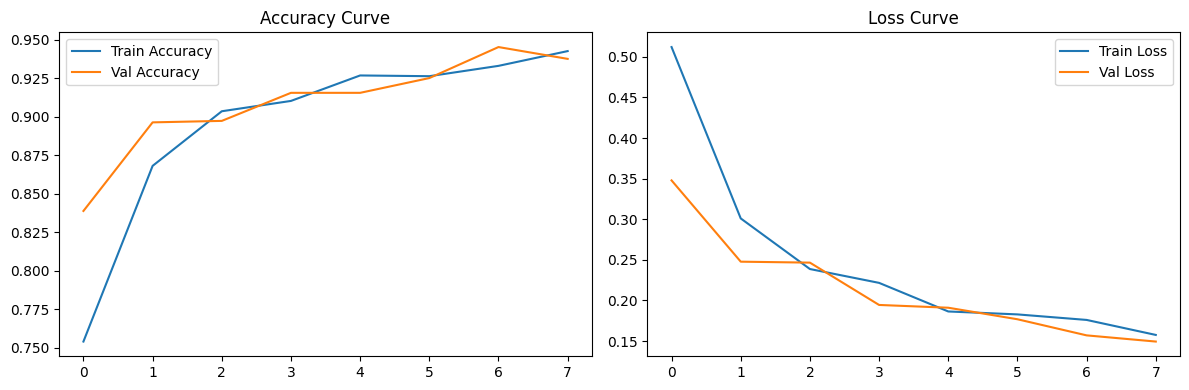

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 448ms/step - accuracy: 0.5365 - loss: 1.2900

📊 测试集准确率: 0.7516
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step

===== 分类报告（作业要求的完整指标） =====
              precision    recall  f1-score   support

      NORMAL       0.98      0.35      0.51       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.85      0.67      0.67       624
weighted avg       0.81      0.75      0.71       624



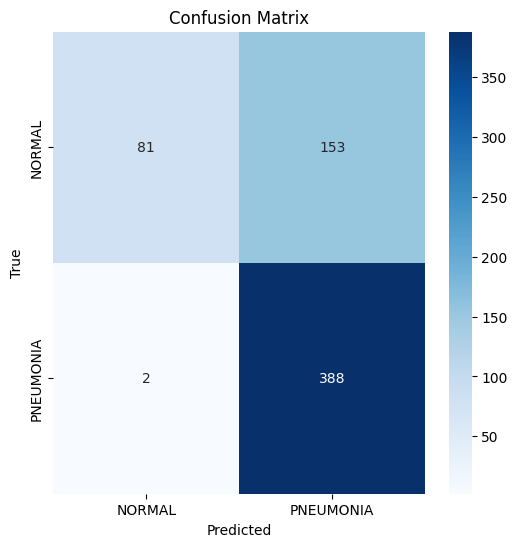

In [7]:
# 强制只用CPU运行，避开GPU问题
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ====================== 1. 正确的数据集路径（适配你的Kaggle） ======================
base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
print(f"✅ 数据集根目录: {base_path}")

# 定义训练/测试路径
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# 统计数据分布（作业要求）
print("\n=== 数据集样本统计 ===")
train_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
test_normal = len(os.listdir(os.path.join(test_dir, 'NORMAL')))
test_pneumonia = len(os.listdir(os.path.join(test_dir, 'PNEUMONIA')))

print(f"训练集：NORMAL={train_normal}, PNEUMONIA={train_pneumonia}")
print(f"测试集：NORMAL={test_normal}, PNEUMONIA={test_pneumonia}")

# ====================== 2. 数据加载与预处理（按8:2划分训练/验证集） ======================
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 训练集生成器（含数据增强+8:2划分）
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 按作业要求从train中划分20%作为验证集
)

# 训练集（80%）
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    subset='training',
    seed=42
)

# 验证集（20%）
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    subset='validation',
    seed=42
)

# 测试集生成器（仅归一化）
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

# ====================== 3. 搭建简单CNN模型（作业方案A） ======================
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n=== 模型结构 ===")
model.summary()

# ====================== 4. 训练模型 ======================
print("\n🚀 开始训练（CPU约5-10分钟）...")
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    verbose=1
)

# ====================== 5. 生成作业要求的图表 ======================
# 1. 训练/验证曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png')
plt.show()

# 2. 测试集评估与混淆矩阵
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n📊 测试集准确率: {test_acc:.4f}")

y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\n===== 分类报告（作业要求的完整指标） =====")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()